In [ ]:
# !pip install matplotlib numpy
import matplotlib.pyplot as plt
import numpy as np
from predictor_new import predict_future

In [ ]:
# Version 1: Horizontal Straight Line
def generate_straight_trajectory_v1(t, start_pos=(0, 0), velocity=(200, 0)):
    """Generate position at time t for straight-line movement"""
    x = start_pos[0] + velocity[0] * t
    y = start_pos[1] + velocity[1] * t
    return (x, y)

# Version 2: Angled Straight Line
def generate_straight_trajectory_v2(t, start_pos=(0, 0), velocity=(30, 30)):
    """Generate position at time t for straight-line movement at 45 degrees"""
    x = start_pos[0] + velocity[0] * t
    y = start_pos[1] + velocity[1] * t
    return (x, y)

# Circle Trajectory
def generate_circle_trajectory(t, center=(200, 200), radius=100, angular_speed=1.0, phase=0):
    """Generate position at time t for circular movement"""
    angle = angular_speed * t + phase
    x = center[0] + radius * np.cos(angle)
    y = center[1] + radius * np.sin(angle)
    return (x, y)

# Version 1: Horizontal Sine Wave
def generate_sine_trajectory_v1(t, start_pos=(0, 0), x_velocity=200, amplitude=50, frequency=2, phase=0):
    """Generate position at time t for sinusoidal movement (horizontal)"""
    x = start_pos[0] + x_velocity * t
    # Simple sine wave based on x position (adjust divisor as needed for wavelength)
    # The divisor controls how many spatial units correspond to one cycle
    y = start_pos[1] + amplitude * np.sin(2 * np.pi * frequency * x / (x_velocity * 1.5) + phase) 
    return (x, y)

# Version 2: Angled Sine Wave
def generate_sine_trajectory_v2(t, start_pos=(0, 0), angle_deg=-45, speed=40, amplitude=50, frequency=2, phase=0):
    """Generate position at time t for sinusoidal movement at an angle"""
    angle_rad = np.radians(angle_deg)
    base_x = start_pos[0] + speed * t * np.cos(angle_rad)
    base_y = start_pos[1] + speed * t * np.sin(angle_rad)
    perp_angle = angle_rad + np.pi/2
    x = base_x + amplitude * np.sin(2 * np.pi * frequency * t + phase) * np.cos(perp_angle)
    y = base_y + amplitude * np.sin(2 * np.pi * frequency * t + phase) * np.sin(perp_angle)
    return (x, y)

def add_noise(positions, noise_level=2.0):
    """Add Gaussian noise to a list of positions"""
    noisy_positions = []
    for pos in positions:
        noise_x = np.random.normal(0, noise_level)
        noise_y = np.random.normal(0, noise_level)
        noisy_positions.append((pos[0] + noise_x, pos[1] + noise_y))
    return noisy_positions

Processing: Straight (Horizontal)
Model errors - Straight: 0.33, Circle: 8.76, Sine: 0.26
Sine model selected but amplitude (0.08) below threshold (1.0).
Defaulting to straight line model instead.
Best model: straight
Processing: Circle
Model errors - Straight: 17534.96, Circle: 34.28, Sine: 1115.53
Best model: circle
Processing: Sine (Horizontal)
Model errors - Straight: 23994.34, Circle: 19733.74, Sine: 26.54
Sine model selected with amplitude: 50.20
Best model: sine


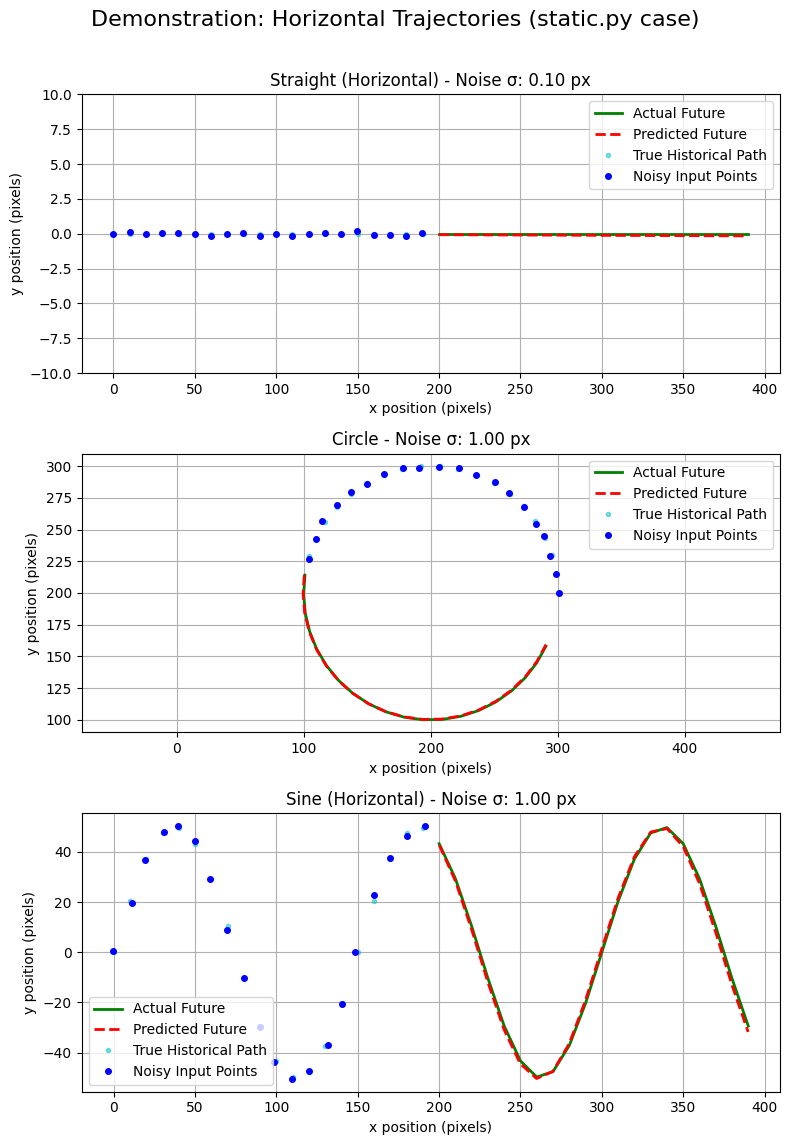

In [3]:
# Simulation parameters for static.py case
dt_v1 = 0.05
n_steps_v1 = 20
future_steps_v1 = 20
noise_level_v1 = 1.0

# Trajectory generators for static.py case
trajectory_generators_v1 = [
    ("Straight (Horizontal)", lambda t: generate_straight_trajectory_v1(t, start_pos=(0, 0), velocity=(200, 0))),
    ("Circle", lambda t: generate_circle_trajectory(t, center=(200, 200), radius=100, angular_speed=3.0)),
    ("Sine (Horizontal)", lambda t: generate_sine_trajectory_v1(t, start_pos=(0, 0), x_velocity=200, amplitude=50, frequency=2))
]

# Create figure
fig1, axes1 = plt.subplots(len(trajectory_generators_v1), 1, figsize=(8, 12))
fig1.suptitle('Demonstration: Horizontal Trajectories (static.py case)', fontsize=16)

np.random.seed(42) # for reproducibility

for i, (name, trajectory_func) in enumerate(trajectory_generators_v1):
    ax = axes1[i]
    print(f"Processing: {name}")

    # Generate trajectory data
    total_steps = n_steps_v1 + future_steps_v1
    all_times = np.arange(0, total_steps * dt_v1, dt_v1)
    all_positions = [trajectory_func(t) for t in all_times]

    history_times = all_times[:n_steps_v1]
    history_pos_clean = all_positions[:n_steps_v1]
    actual_future_times = all_times[n_steps_v1:total_steps]
    actual_future_pos = all_positions[n_steps_v1:total_steps]

    # Add noise
    current_noise = noise_level_v1
    if name == "Straight (Horizontal)":
        # Less noise for straight line for better visualization
        current_noise = noise_level_v1 / 10 
        ax.set_ylim(-10, 10) # Zoom in for straight line
    history_pos_noisy = add_noise(history_pos_clean, current_noise)

    # Prepare history for predictor
    time_position_history = [[t, pos[0], pos[1]] for t, pos in zip(history_times, history_pos_noisy)]

    # Predict future
    predicted_future = predict_future(
        time_position_history, 
        future_times=actual_future_times,
        num_points=future_steps_v1
    )

    # Convert to numpy arrays for plotting
    history_np_clean = np.array(history_pos_clean)
    history_np_noisy = np.array(history_pos_noisy)
    actual_future_np = np.array(actual_future_pos)
    # Ensure predicted_future is not empty before converting
    predicted_future_np = np.array(predicted_future) if predicted_future else np.empty((0,2))

    # --- Plotting ---
    # Plot actual future (ground truth)
    ax.plot(actual_future_np[:, 0], actual_future_np[:, 1], 'g-', label="Actual Future", linewidth=2)
    
    # Plot predicted future if available
    if predicted_future_np.shape[0] > 0:
        ax.plot(predicted_future_np[:, 0], predicted_future_np[:, 1], 'r--', label="Predicted Future", linewidth=2)
    
    # Plot clean history (faded)
    ax.plot(history_np_clean[:, 0], history_np_clean[:, 1], 'c.', alpha=0.5, label="True Historical Path")
    
    # Plot noisy history (input to predictor)
    ax.plot(history_np_noisy[:, 0], history_np_noisy[:, 1], 'bo', markersize=4, label="Noisy Input Points")
    
    # Add titles and labels
    ax.set_title(f"{name} - Noise σ: {current_noise:.2f} px")
    ax.set_xlabel("x position (pixels)")
    ax.set_ylabel("y position (pixels)")
    ax.legend()
    ax.grid(True)
    
    # Set aspect ratio for circle
    if "Circle" in name:
        ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust layout to prevent title overlap
plt.show()

Processing: Straight (45°)
Model errors - Straight: 2.86, Circle: 337.85, Sine: 2.62
Sine model selected but amplitude (0.11) below threshold (1.0).
Defaulting to straight line model instead.
Best model: straight
Processing: Circle
Model errors - Straight: 22289.97, Circle: 65.96, Sine: 22292.13
Best model: circle
Processing: Sine (-45°)
Model errors - Straight: 48318.00, Circle: 85907.18, Sine: 80.18
Sine model selected with amplitude: 49.99
Best model: sine


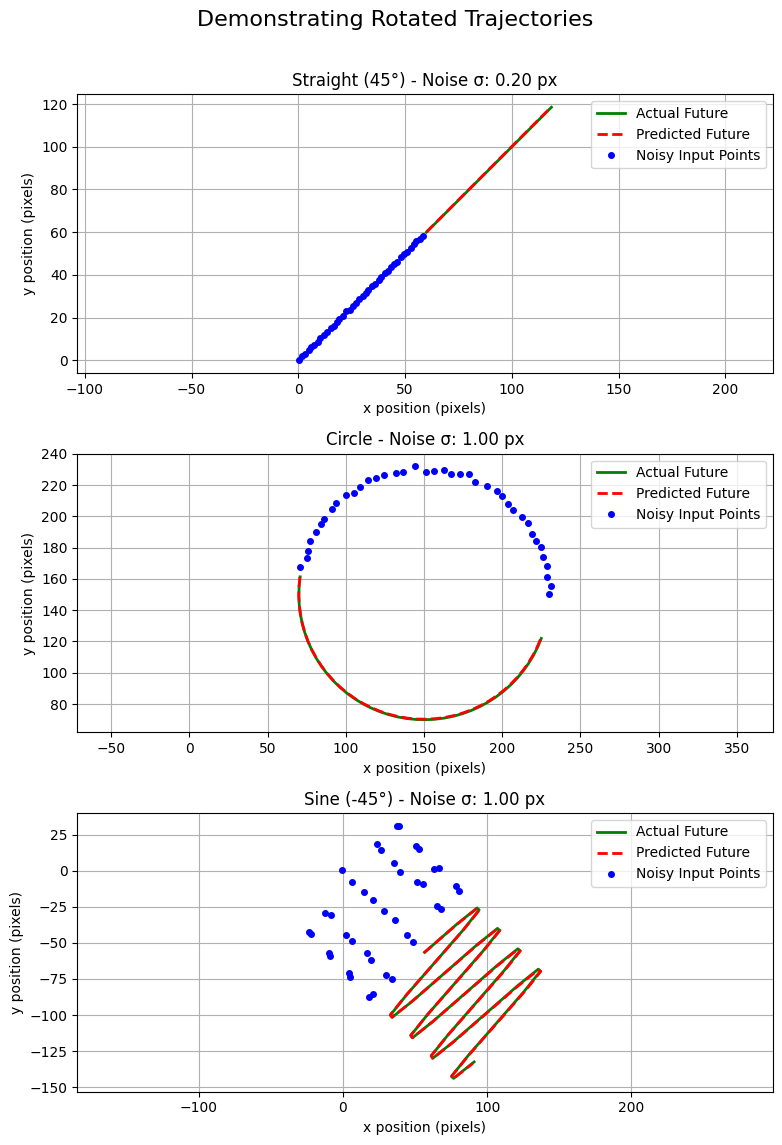

In [5]:
# Simulation parameters for static_rotated.py case
dt_v2 = 0.05
n_steps_v2 = 40
future_steps_v2 = 40
noise_level_v2 = 1.0

# Trajectory generators for static_rotated.py case
trajectory_generators_v2 = [
    ("Straight (45°)", lambda t: generate_straight_trajectory_v2(t, start_pos=(0, 0), velocity=(30, 30))),
    # Using different circle parameters for variety
    ("Circle", lambda t: generate_circle_trajectory(t, center=(150, 150), radius=80, angular_speed=1.5)), 
    ("Sine (-45°)", lambda t: generate_sine_trajectory_v2(t, start_pos=(0, 0), angle_deg=-45, speed=40, amplitude=50, frequency=2))
]

# Create figure
fig2, axes2 = plt.subplots(len(trajectory_generators_v2), 1, figsize=(8, 12))
fig2.suptitle('Demonstrating Rotated Trajectories', fontsize=16)

np.random.seed(42) # for reproducibility

for i, (name, trajectory_func) in enumerate(trajectory_generators_v2):
    ax = axes2[i]
    print(f"Processing: {name}")

    # Generate trajectory data
    total_steps = n_steps_v2 + future_steps_v2
    all_times = np.arange(0, total_steps * dt_v2, dt_v2)
    all_positions = [trajectory_func(t) for t in all_times]

    history_times = all_times[:n_steps_v2]
    history_pos_clean = all_positions[:n_steps_v2]
    actual_future_times = all_times[n_steps_v2:total_steps]
    actual_future_pos = all_positions[n_steps_v2:total_steps]

    # Add noise
    current_noise = noise_level_v2
    if "Straight" in name:
        # Less noise for straight line
        current_noise = noise_level_v2 / 5 
    history_pos_noisy = add_noise(history_pos_clean, current_noise)

    # Prepare history for predictor
    time_position_history = [[t, pos[0], pos[1]] for t, pos in zip(history_times, history_pos_noisy)]

    # Predict future
    predicted_future = predict_future(
        time_position_history, 
        future_times=actual_future_times,
        num_points=future_steps_v2
    )

    # Convert to numpy arrays for plotting
    history_np_clean = np.array(history_pos_clean)
    history_np_noisy = np.array(history_pos_noisy)
    actual_future_np = np.array(actual_future_pos)
    # Ensure predicted_future is not empty before converting
    predicted_future_np = np.array(predicted_future) if predicted_future else np.empty((0,2))

    # --- Plotting ---
    # Plot actual future (ground truth)
    ax.plot(actual_future_np[:, 0], actual_future_np[:, 1], 'g-', label="Actual Future", linewidth=2)
    
    # Plot predicted future if available
    if predicted_future_np.shape[0] > 0:
        ax.plot(predicted_future_np[:, 0], predicted_future_np[:, 1], 'r--', label="Predicted Future", linewidth=2)
    
    # Plot clean history (faded)
    # ax.plot(history_np_clean[:, 0], history_np_clean[:, 1], 'c.', alpha=0.5, label="True Historical Path")
    
    # Plot noisy history (input)
    ax.plot(history_np_noisy[:, 0], history_np_noisy[:, 1], 'bo', markersize=4, label="Noisy Input Points")

    ax.set_title(f"{name} - Noise σ: {current_noise:.2f} px")
    ax.set_xlabel("x position (pixels)")
    ax.set_ylabel("y position (pixels)")
    ax.legend()
    ax.grid(True)
    
    ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()